In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib3
import requests
import io
import re

# Indlæs data

In [2]:
# Remove warings when downloading files from GitHub
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Download files from GitHub API
api_url = "https://api.github.com/repos/Mathias2209/Dataprojekt/contents/folder-Data/folder-2023%20AAR%20vaskeri%20data"
response = requests.get(api_url, verify=False)
filer = response.json()

# Filter for Excel files that start with "PLC"
xlsx_filer = [f for f in filer if f["name"].startswith("PLC") and f["name"].endswith(".xlsx")]


# Load each Excel file into a DataFrame and concatenate them
dataframes = []
for fil in xlsx_filer:
    r = requests.get(fil["download_url"], verify=False)
    df = pd.read_excel(io.BytesIO(r.content), skiprows=2)
    
    # Extract month from filename (e.g. "PLC_Januar_2023.xlsx" -> "Januar")
    match = re.search(r'(januar|februar|marts|april|maj|juni|juli|august|september|oktober|november|december)', 
                      fil["name"], re.IGNORECASE)
    df["Måned"] = match.group(1).capitalize() if match else fil["name"]

    dataframes.append(df)

# Concatenate all DataFrames into one
df = pd.concat(dataframes, ignore_index=True)

### Gentagelser af "Unikke koder"

In [6]:
n_unique_prod_year = (
    df
    .dropna(subset=["Unik Kode (ui)"])
    .groupby("Unik Kode (ui)")["Produkt - Produkt"] #group by ui and look at product for each group
    .nunique() #counting how many products each ui maps to
)
bad_ui_year = n_unique_prod_year[n_unique_prod_year > 1].index #filter for only conflicting ui's

conflicts_year = (
            df[df["Unik Kode (ui)"].isin(bad_ui_year)] #selecting rows which ui's are non-unique
            .loc[:, ["Unik Kode (ui)", "Produkt - Produkt"]] # selecting only the stated rows
            .drop_duplicates() #dropping duplicates of bad ui's (same prod, same ui, same file)
            .sort_values(["Unik Kode (ui)", "Produkt - Produkt"]) #sorting for readability
        )

print("Number of conflicting UI codes in full dataset:", len(bad_ui_year))
conflicts_year.head(7)

Number of conflicting UI codes in full dataset: 439


,Unik Kode (ui),Produkt - Produkt
83199,00D007440139,09182 Overall Kblå Hygiejne
100711,00D007440139,23361 Overall Food Kblå
26700,00D0075C79CB,06325 Kokkebuss. Brod. Grå P/B
39935,00D0075C79CB,30206 Jakke Løvbjerg sort
55818,00D0085C7770,01806 Jakke Termo Marineblå
79324,00D0085C7770,23897 Termojakke u/lom mblå
89563,00D0085D8F1F,09182 Overall Kblå Hygiejne


### Plot/ Tabel

In [21]:
# Filtrer df for kun at beholde de koder, der har konflikter
conflicts_raw = df[df["Unik Kode (ui)"].isin(bad_ui_year)]

# Aggreger til én række pr. kode med lister
conflicts_grouped = (
    conflicts_raw
    .groupby("Unik Kode (ui)")
    .agg({
        "Produkt - Produkt": lambda x: list(x.unique()),
        "Dage i cirkulation": list,
        "Kassationsårsag (ui)": list
    })
    .reset_index()
)

# Omdøb kolonner for klarhed
conflicts_grouped.columns = ["Unik Kode (ui)", "Produktnavne", "Dage_Historik", "Aarsager_Historik"]

conflicts_grouped.head(10)

,Unik Kode (ui),Produktnavne,Dage_Historik,Aarsager_Historik
0,00D007440139,"[09182 Overall Kblå Hygiejne, 23361 Overall Fo...","[1626, 0]","[Udgået Model, Udgået Model]"
1,00D0075C79CB,"[06325 Kokkebuss. Brod. Grå P/B, 30206 Jakke L...","[1361, 0, 0]","[BTS fejl uden restværdi, BTS fejl uden restvæ..."
2,00D0085C7770,"[01806 Jakke Termo Marineblå, 23897 Termojakke...","[3997, 0]","[Misligholdt med restværdi, BTS fejl uden rest..."
3,00D0085D8F1F,"[09182 Overall Kblå Hygiejne, 23361 Overall Fo...","[743, 0]","[Udgået Model, Udgået Model]"
4,00D00960C27E,"[10129 Overall FlmQ so/grå brystlom, 25995 Ove...","[98, 0]","[Udgået Model, Alm.slid uden restværdi]"
5,00D009AFC9AD,"[22571 Dunjakke Outdoor C uni sort, 13694 Jakk...","[445, 60]","[Udgået Model, Udgået Model]"
6,00D009E24B0F,"[14147 Jakke 2 indvlom hv high risk, 14141 Jak...","[0, 38]","[Videresalg til kunder, Misligholdt med restvæ..."
7,00D00A2B05E2,"[25996 Buks FlamePro NY sort/grå, 13210 Benklæ...","[27, 1756]","[Misligholdt med restværdi, Udgået Model]"
8,00D00A57D4D1,"[09195 Overall M.Knæl Grå/Sort Bom, 02813 Over...","[0, 0]","[Udgået Model, Udgået Model]"
9,00D00A5CFA2D,"[09182 Overall Kblå Hygiejne, 23361 Overall Fo...","[399, 262]","[Udgået Model, Udgået Model]"


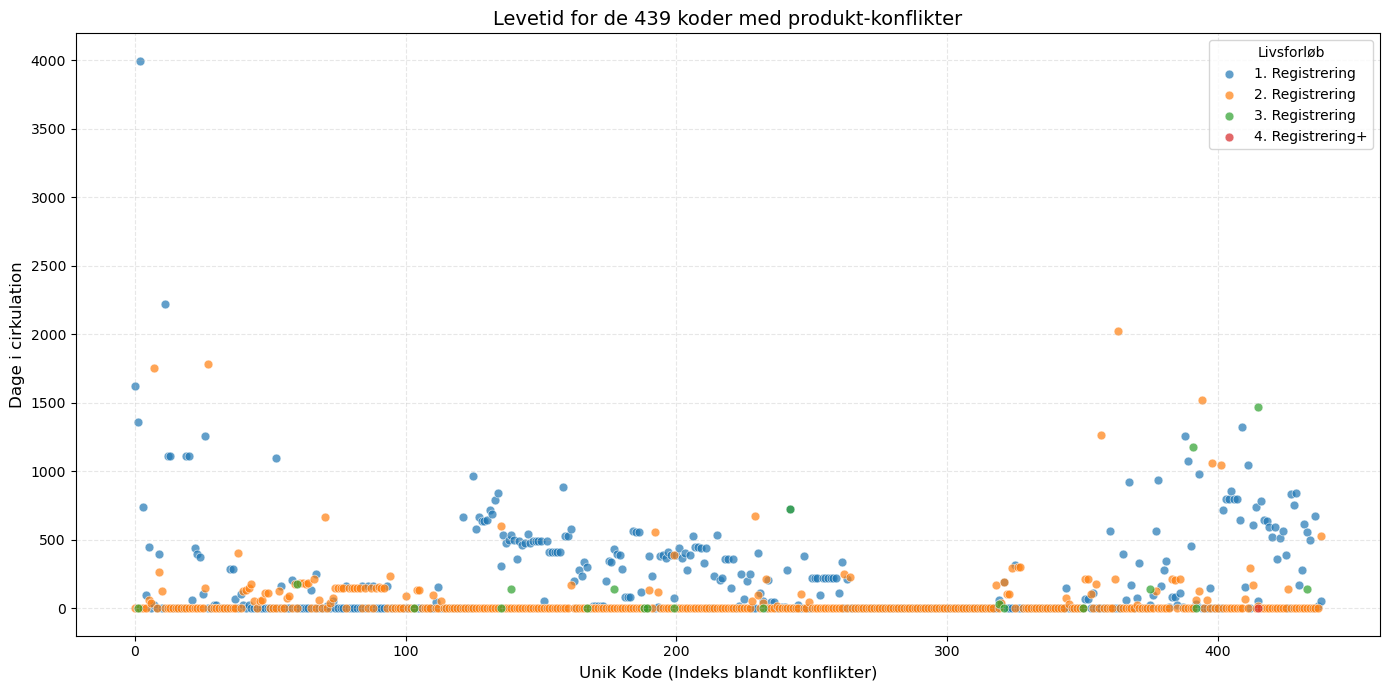

In [8]:
# 4. Forbered data til scatterplot (Kun for konflikterne)
plot_data = []
for i, row in conflicts_grouped.iterrows():
    for index, dage in enumerate(row['Dage_Historik']):
        plot_data.append({
            'ID_Index': i, 
            'Dage': dage, 
            'Liv_Nummer': index + 1
        })

plot_df = pd.DataFrame(plot_data)

# 5. Generer scatterplot
plt.figure(figsize=(14, 7))
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
labels = {1: '1. Registrering', 2: '2. Registrering', 3: '3. Registrering', 4: '4. Registrering+'}

for life in sorted(plot_df['Liv_Nummer'].unique()):
    subset = plot_df[plot_df['Liv_Nummer'] == life]
    plt.scatter(subset['ID_Index'], subset['Dage'], 
                color=colors.get(life, 'black'), 
                label=labels.get(life), 
                alpha=0.7, s=40, edgecolors='w', linewidth=0.5)

plt.title(f'Levetid for de {len(conflicts_grouped)} koder med produkt-konflikter', fontsize=14)
plt.xlabel('Unik Kode (Indeks blandt konflikter)', fontsize=12)
plt.ylabel('Dage i cirkulation', fontsize=12)
plt.legend(title="Livsforløb")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Vis de første 10 rækker af den nye tabel
# print(f"Tabel over de {len(conflicts_grouped)} koder med konflikter:")
# conflicts_grouped.head(10)

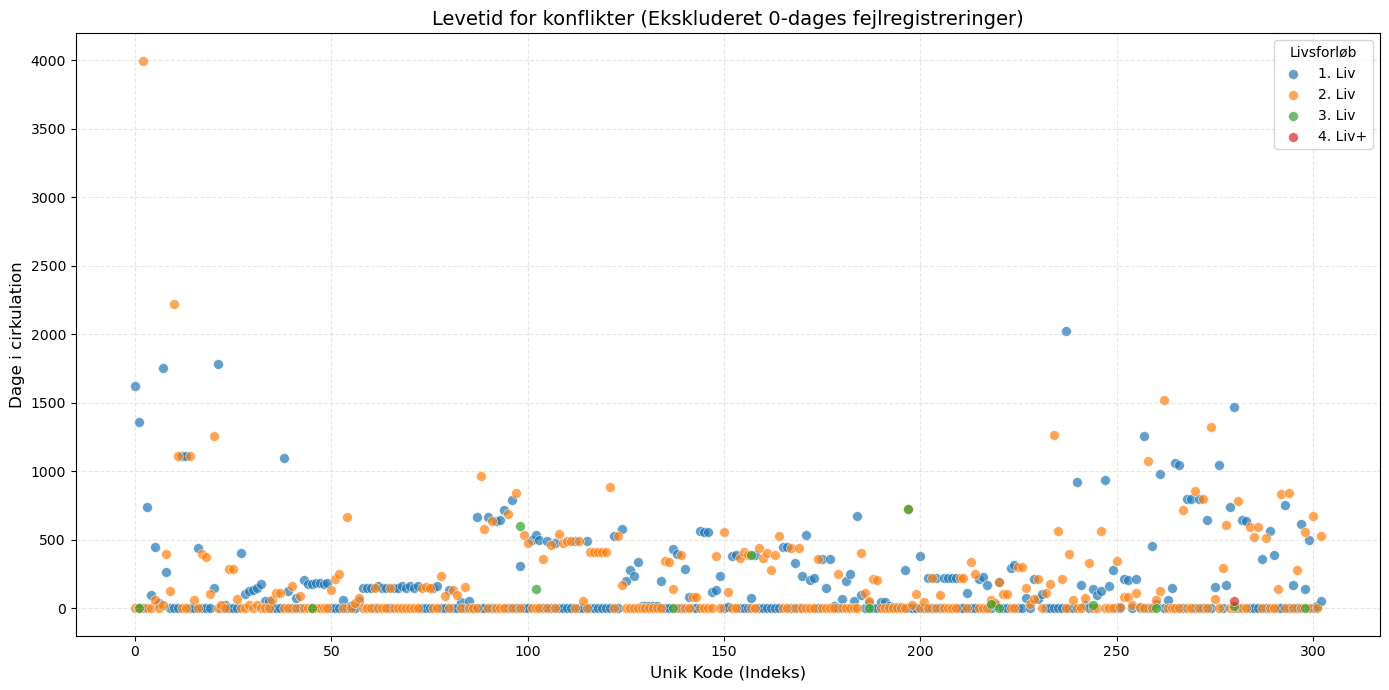

Oprindelige konflikter: 439
Konflikter efter fjernelse af 0-dages registreringer: 303


In [11]:
# 2. Aggregering til én række pr. UI
conflicts_raw = df[df["Unik Kode (ui)"].isin(bad_ui_year)].copy()
# Vi sikrer os at de er sorteret efter måned (Month_Num skal være oprettet tidligere)
conflicts_raw = conflicts_raw.sort_values(['Unik Kode (ui)'])

conflicts_grouped = (
    conflicts_raw
    .groupby("Unik Kode (ui)")
    .agg({
        "Produkt - Produkt": lambda x: list(x.unique()),
        "Dage i cirkulation": list,
        "Kassationsårsag (ui)": list
    })
    .reset_index()
)

# 3. FILTRERING: Fjern dem med 0 i både 1. og 2. levetid
# Vi definerer en maske der finder dem hvor både første (index 0) og anden (index 1) værdi er 0
mask_both_zero = (
    conflicts_grouped['Dage i cirkulation'].apply(lambda x: x[0] if len(x) > 0 else None) == 0
) & (
    conflicts_grouped['Dage i cirkulation'].apply(lambda x: x[1] if len(x) > 1 else None) == 0
)

# Vi beholder kun dem der IKKE (~) matcher masken
conflicts_filtered = conflicts_grouped[~mask_both_zero].copy()

# 4. Forbered data til scatterplot (Nu med det filtrerede sæt)
plot_data = []
for i, row in conflicts_filtered.reset_index().iterrows():
    for index, dage in enumerate(row['Dage i cirkulation']):
        plot_data.append({
            'ID_Index': i, 
            'Dage': dage, 
            'Liv_Nummer': index + 1
        })

plot_df = pd.DataFrame(plot_data)

# 5. Scatterplot over de reelle konflikter
plt.figure(figsize=(14, 7))
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
labels = {1: '1. Liv', 2: '2. Liv', 3: '3. Liv', 4: '4. Liv+'}

for life in sorted(plot_df['Liv_Nummer'].unique()):
    subset = plot_df[plot_df['Liv_Nummer'] == life]
    plt.scatter(subset['ID_Index'], subset['Dage'], 
                color=colors.get(life, 'black'), 
                label=labels.get(life), 
                alpha=0.7, s=50, edgecolors='w', linewidth=0.5)

plt.title(f'Levetid for konflikter (Ekskluderet 0-dages fejlregistreringer)', fontsize=14)
plt.xlabel('Unik Kode (Indeks)', fontsize=12)
plt.ylabel('Dage i cirkulation', fontsize=12)
plt.legend(title="Livsforløb")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Oprindelige konflikter: {len(conflicts_grouped)}")
print(f"Konflikter efter fjernelse af 0-dages registreringer: {len(conflicts_filtered)}")

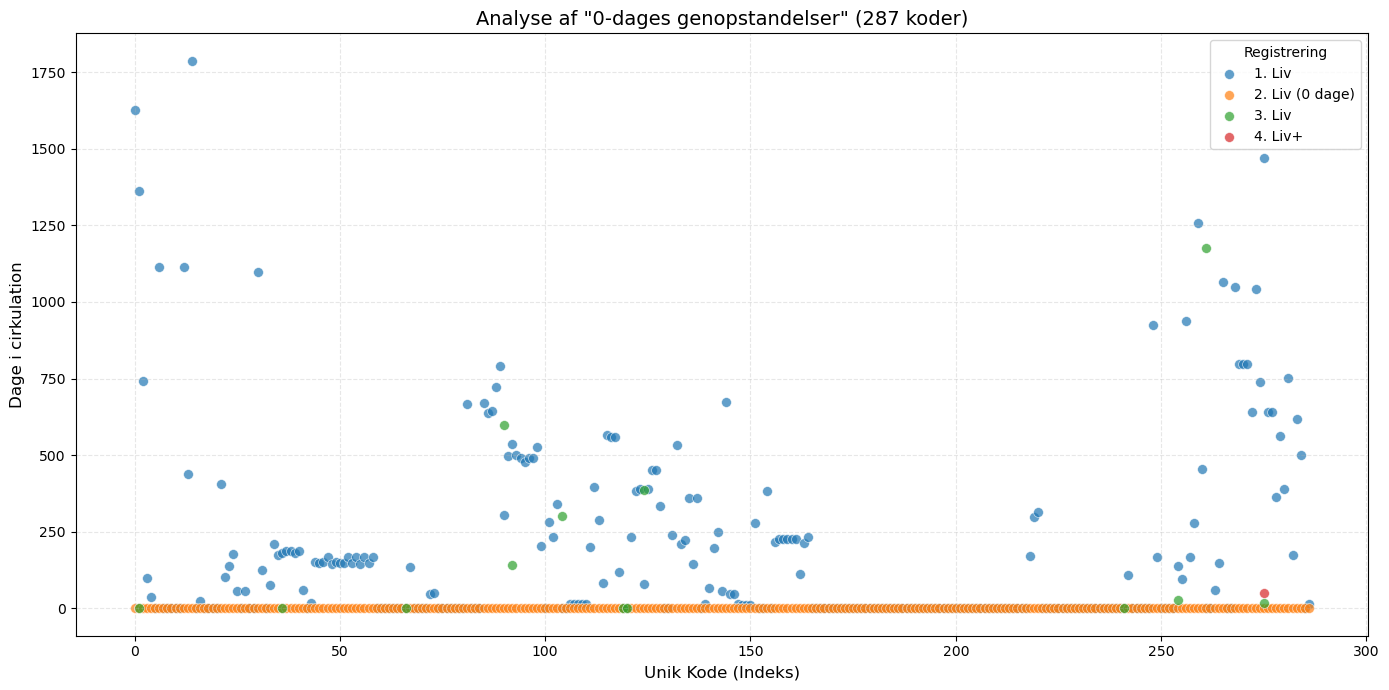

Antal koder hvor 2. liv er præcis 0 dage: 287


In [ ]:
# filtrer for koder, der har mindst to registreringer, hvor den anden er 0
mask_second_life_zero = (
    conflicts_grouped['Dage i cirkulation'].apply(lambda x: len(x) > 1 and x[1] == 0)
)

conflicts_zero_second = conflicts_grouped[mask_second_life_zero].copy()

# 2. Forbered data til plot
plot_data_zero = []
for i, row in conflicts_zero_second.reset_index().iterrows():
    for index, dage in enumerate(row['Dage i cirkulation']):
        plot_data_zero.append({
            'ID_Index': i, 
            'Dage': dage, 
            'Liv_Nummer': index + 1
        })

plot_df_zero = pd.DataFrame(plot_data_zero)

# Scatterplot
plt.figure(figsize=(14, 7))
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
labels = {1: '1. Liv', 2: '2. Liv (0 dage)', 3: '3. Liv', 4: '4. Liv+'}

for life in sorted(plot_df_zero['Liv_Nummer'].unique()):
    subset = plot_df_zero[plot_df_zero['Liv_Nummer'] == life]
    plt.scatter(subset['ID_Index'], subset['Dage'], 
                color=colors.get(life, 'black'), 
                label=labels.get(life), 
                alpha=0.7, s=50, edgecolors='w', linewidth=0.5)

plt.title(f'Analyse af "0-dages genopstandelser" ({len(conflicts_zero_second)} koder)', fontsize=14)
plt.xlabel('Unik Kode (Indeks)', fontsize=12)
plt.ylabel('Dage i cirkulation', fontsize=12)
plt.legend(title="Registrering")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Antal koder hvor 2. liv er præcis 0 dage: {len(conflicts_zero_second)}")

## Stk. tøj $>1$

In [22]:
# Filtrering 
Stktoej = df[df["Stk. tøj per kassationsdato"] > 1]

# Sortering efter antal
Stktoej_tabel = (
    Stktoej[["Unik Kode (ui)", "Produkt - Produkt", "Kassationsårsag (ui)", "Stk. tøj per kassationsdato"]]
    .sort_values(by="Stk. tøj per kassationsdato", ascending=False)
)

print(f"Antal rækker med \"Stk. tøj per kassationsdato\" (>1 stk): {len(Stktoej)}")

print(Stktoej["Kassationsårsag (ui)"].value_counts())

Antal rækker med "Stk. tøj per kassationsdato" (>1 stk): 553
Kassationsårsag (ui)
Udgået Model                           463
Alm.slid uden restværdi                 45
BTS fejl uden restværdi                 43
Produktfejl                              1
Ødelagt af lommefyld uden restværdi      1
Name: count, dtype: int64


In [23]:
andel = (len(Stktoej) / len(df) * 100)
print(f"Andel af rækker med \"Stk. tøj per kassationsdato\" > 1: \n{len(Stktoej)} / {len(df)} * 100 = {andel:.2f}%")

Andel af rækker med "Stk. tøj per kassationsdato" > 1: 
553 / 248711 * 100 = 0.22%
